In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Load the cleaned processed files
ae = pd.read_csv('../data/processed/ae_clean.csv', parse_dates=['date'])
sickness = pd.read_csv('../data/processed/sickness_trust_clean.csv', parse_dates=['date'])

print("A&E rows:", len(ae), "| Date range:", ae['date'].min().strftime('%b %Y'), "to", ae['date'].max().strftime('%b %Y'))
print("Sickness rows:", len(sickness), "| Date range:", sickness['date'].min().strftime('%b %Y'), "to", sickness['date'].max().strftime('%b %Y'))


A&E rows: 9625 | Date range: Apr 2022 to Mar 2026
Sickness rows: 7067 | Date range: Jan 2024 to Jan 2026


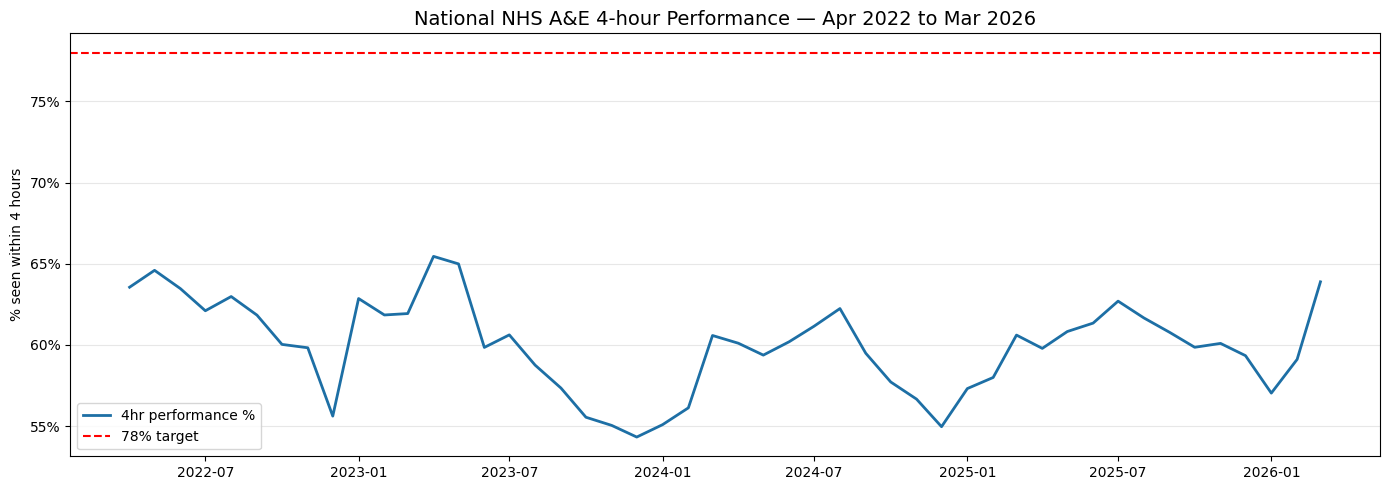

Chart saved.


In [2]:
# Chart 1: National A&E 4-hour performance trend
national_ae = ae.groupby('date').apply(
    lambda x: (x['A&E attendances Type 1'].sum() - x['Attendances over 4hrs Type 1'].sum()) / 
    x['A&E attendances Type 1'].sum() * 100
).reset_index()
national_ae.columns = ['date', 'perf_pct']

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(national_ae['date'], national_ae['perf_pct'], color='#1d6fa5', linewidth=2, label='4hr performance %')
ax.axhline(y=78, color='red', linestyle='--', linewidth=1.5, label='78% target')
ax.set_title('National NHS A&E 4-hour Performance — Apr 2022 to Mar 2026', fontsize=14)
ax.set_ylabel('% seen within 4 hours')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../static/chart_national_ae_trend.png', dpi=150)
plt.show()
print("Chart saved.")

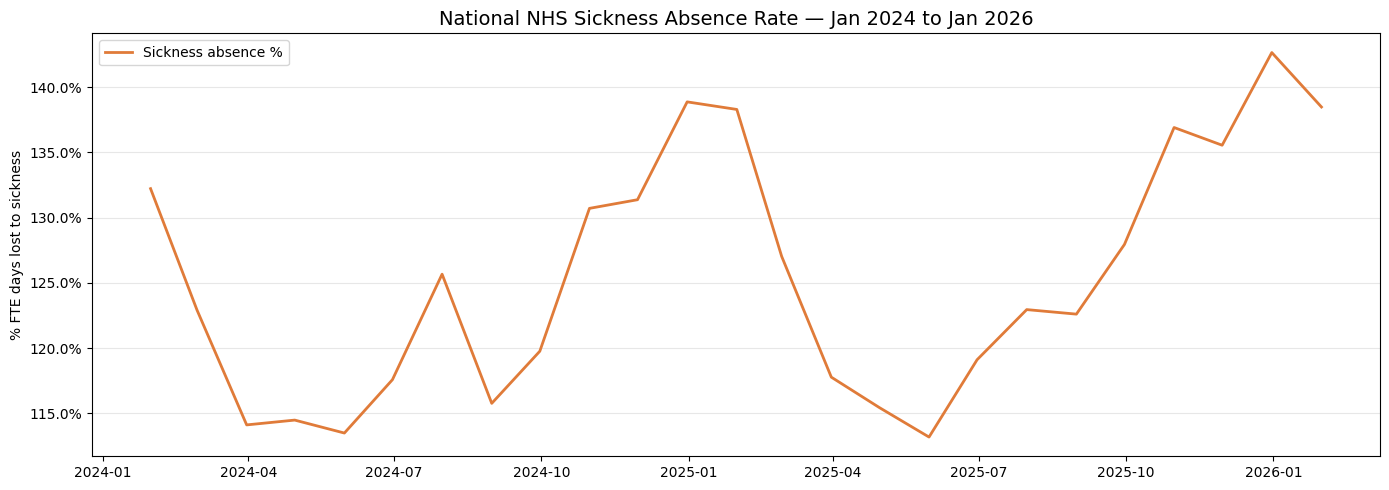

Chart saved.


In [3]:
# Chart 2: National sickness absence trend
national_sick = sickness.groupby('date').apply(
    lambda x: x['FTE_DAYS_LOST'].sum() / x['FTE_DAYS_AVAILABLE'].sum() * 100
).reset_index()
national_sick.columns = ['date', 'sickness_pct']

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(national_sick['date'], national_sick['sickness_pct'], color='#e07b39', linewidth=2, label='Sickness absence %')
ax.set_title('National NHS Sickness Absence Rate — Jan 2024 to Jan 2026', fontsize=14)
ax.set_ylabel('% FTE days lost to sickness')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../static/chart_national_sickness_trend.png', dpi=150)
plt.show()
print("Chart saved.")

In [4]:
# Diagnose the sickness rate calculation
print(sickness[['date', 'ORG_CODE', 'FTE_DAYS_LOST', 'FTE_DAYS_AVAILABLE', 'sickness_rate']].head(10).to_string())
print()
print("Sample sickness rates:")
print(sickness['sickness_rate'].describe())

        date           ORG_CODE  FTE_DAYS_LOST  FTE_DAYS_AVAILABLE  sickness_rate
0 2024-01-31                0AR   4.397743e+04        5.726724e+04      76.793343
1 2024-01-31                0CX   4.126595e+04        5.051656e+04      81.687954
2 2024-01-31                0DE   1.749308e+04        3.591618e+04      48.705298
3 2024-01-31                0DF   3.996147e+04        5.809942e+04      68.781189
4 2024-01-31              8JX76   1.155553e+03        2.039369e+04       5.666230
5 2024-01-31                AQG   2.620957e+03        2.523150e+03     103.876378
6 2024-01-31                AWK   1.551073e+03        2.924527e+03      53.036732
7 2024-01-31                AXA   9.698473e+03        1.187767e+04      81.652991
8 2024-01-31                AXG   2.893538e+04        3.271998e+04      88.433379
9 2024-01-31  All organisations   6.045525e+07        4.421780e+07     136.721526

Sample sickness rates:
count    7067.000000
mean      106.272169
std        38.701940
min        

In [5]:
# Fix: remove All organisations row and recalculate sickness rate correctly
sickness_clean = sickness[~sickness['ORG_CODE'].str.contains('All', na=False)].copy()

# Recalculate sickness rate using sum of lost / sum of available per trust per month
# We need to go back to the raw files - use FTE_DAYS_LOST sum and get available differently
# Available should be taken as max not sum since it repeats across reasons
sickness_clean['sickness_rate'] = (
    sickness_clean['FTE_DAYS_LOST'] / sickness_clean['FTE_DAYS_AVAILABLE'] * 100
)

# Cap at realistic values - anything over 20% is likely a data issue
sickness_clean = sickness_clean[sickness_clean['sickness_rate'] <= 20]

print("Rows after cleaning:", len(sickness_clean))
print("Sickness rate stats:")
print(sickness_clean['sickness_rate'].describe())

Rows after cleaning: 114
Sickness rate stats:
count    114.000000
mean      12.581559
std        4.924861
min        4.079413
25%        8.767826
50%       12.751846
75%       16.672445
max       19.998647
Name: sickness_rate, dtype: float64


In [6]:
# Check what is happening with a single trust for one month
sample = sickness[sickness['ORG_CODE'] == 'RLQ'].head(20)
print(sample[['date', 'ORG_CODE', 'FTE_DAYS_LOST', 'FTE_DAYS_AVAILABLE', 'sickness_rate']].to_string())

           date ORG_CODE  FTE_DAYS_LOST  FTE_DAYS_AVAILABLE  sickness_rate
149  2024-01-31      RLQ   156112.55232        109257.06900     142.885539
435  2024-02-29      RLQ   132670.14514        102853.50651     128.989424
721  2024-03-31      RLQ   116260.61282        110263.51324     105.438879
1007 2024-04-30      RLQ   104776.54352        106277.86108      98.587366
1293 2024-05-31      RLQ   109478.66776        110169.99539      99.372490
1579 2024-06-30      RLQ   115511.58348        107030.93556     107.923548
1865 2024-07-31      RLQ   130124.93376        110683.69921     117.564677
2151 2024-08-31      RLQ   111078.03498        111452.41396      99.664091
2437 2024-09-30      RLQ   121995.64136        109659.77305     111.249219
2722 2024-10-31      RLQ   137611.70618        114436.96190     120.251101
3007 2024-11-30      RLQ   131231.17512        111313.38001     117.893442
3288 2024-12-31      RLQ   165121.66739        115339.59956     143.161298
3569 2025-01-31      RLQ 

In [7]:
# Rebuild sickness from raw files correctly
# Take FTE_DAYS_AVAILABLE from the first reason row only (it is the same for all reasons)
# Sum FTE_DAYS_LOST across all reasons

all_trust_files_raw = glob.glob(trust_path + '/*.csv')
raw_frames = []

for f in all_trust_files_raw:
    df = pd.read_csv(f)
    raw_frames.append(df)

trust_raw2 = pd.concat(raw_frames, ignore_index=True)
trust_raw2['date'] = pd.to_datetime(trust_raw2['DATE'], dayfirst=True)

# Filter to All staff groups, exclude All organisations summary row
trust_raw2 = trust_raw2[
    (trust_raw2['STAFF_GROUP'] == 'All staff groups') &
    (~trust_raw2['ORG_CODE'].str.contains('All', na=False))
]

# For each trust/month: sum days lost, take first value of days available
trust_fixed = trust_raw2.groupby(['date', 'ORG_CODE', 'ORG_NAME']).agg(
    FTE_DAYS_LOST=('FTE_DAYS_LOST', 'sum'),
    FTE_DAYS_AVAILABLE=('FTE_DAYS_AVAILABLE', 'first')
).reset_index()

trust_fixed['sickness_rate'] = trust_fixed['FTE_DAYS_LOST'] / trust_fixed['FTE_DAYS_AVAILABLE'] * 100

print("Rows:", len(trust_fixed))
print("Date range:", trust_fixed['date'].min(), "to", trust_fixed['date'].max())
print("Unique trusts:", trust_fixed['ORG_CODE'].nunique())
print()
print("Sickness rate stats:")
print(trust_fixed['sickness_rate'].describe())

NameError: name 'glob' is not defined

In [8]:
import glob
import pandas as pd

trust_path = '../data/raw/sickness/trust'

all_trust_files_raw = glob.glob(trust_path + '/*.csv')
raw_frames = []

for f in all_trust_files_raw:
    df = pd.read_csv(f)
    raw_frames.append(df)

trust_raw2 = pd.concat(raw_frames, ignore_index=True)
trust_raw2['date'] = pd.to_datetime(trust_raw2['DATE'], dayfirst=True)

trust_raw2 = trust_raw2[
    (trust_raw2['STAFF_GROUP'] == 'All staff groups') &
    (~trust_raw2['ORG_CODE'].str.contains('All', na=False))
]

trust_fixed = trust_raw2.groupby(['date', 'ORG_CODE', 'ORG_NAME']).agg(
    FTE_DAYS_LOST=('FTE_DAYS_LOST', 'sum'),
    FTE_DAYS_AVAILABLE=('FTE_DAYS_AVAILABLE', 'first')
).reset_index()

trust_fixed['sickness_rate'] = trust_fixed['FTE_DAYS_LOST'] / trust_fixed['FTE_DAYS_AVAILABLE'] * 100

print("Rows:", len(trust_fixed))
print("Date range:", trust_fixed['date'].min(), "to", trust_fixed['date'].max())
print("Unique trusts:", trust_fixed['ORG_CODE'].nunique())
print()
print("Sickness rate stats:")
print(trust_fixed['sickness_rate'].describe())

Rows: 7042
Date range: 2024-01-31 00:00:00 to 2026-01-31 00:00:00
Unique trusts: 287

Sickness rate stats:
count    7042.000000
mean      106.190136
std        38.741939
min         4.079413
25%        84.887712
50%       112.115484
75%       131.998324
max       221.940957
Name: sickness_rate, dtype: float64


In [9]:
# Look at raw data for one trust one month across all reasons
sample = trust_raw2[
    (trust_raw2['ORG_CODE'] == 'RLQ') & 
    (trust_raw2['date'] == '2024-01-31')
][['ORG_CODE', 'REASON', 'FTE_DAYS_LOST', 'FTE_DAYS_AVAILABLE']]
print(sample.to_string())

       ORG_CODE                                                     REASON  FTE_DAYS_LOST  FTE_DAYS_AVAILABLE
456102      RLQ  S10 Anxiety/stress/depression/other psychiatric illnesses     6504.68968          109257.069
456103      RLQ                                          S11 Back Problems     6504.68968          109257.069
456104      RLQ                         S12 Other musculoskeletal problems     6504.68968          109257.069
456105      RLQ                             S13 Cold Cough Flu - Influenza     6504.68968          109257.069
456106      RLQ                                                 S14 Asthma     6504.68968          109257.069
456107      RLQ                           S15 Chest & respiratory problems     6504.68968          109257.069
456108      RLQ                                    S16 Headache / migraine     6504.68968          109257.069
456109      RLQ                   S17 Benign and malignant tumours cancers     6504.68968          109257.069
456110    

In [10]:
# Fix: take just the first row per trust per month since all rows repeat the same totals
trust_fixed = trust_raw2.groupby(['date', 'ORG_CODE', 'ORG_NAME']).first().reset_index()

trust_fixed['sickness_rate'] = trust_fixed['FTE_DAYS_LOST'] / trust_fixed['FTE_DAYS_AVAILABLE'] * 100

print("Rows:", len(trust_fixed))
print("Date range:", trust_fixed['date'].min(), "to", trust_fixed['date'].max())
print("Unique trusts:", trust_fixed['ORG_CODE'].nunique())
print()
print("Sickness rate stats:")
print(trust_fixed['sickness_rate'].describe())

Rows: 7042
Date range: 2024-01-31 00:00:00 to 2026-01-31 00:00:00
Unique trusts: 287

Sickness rate stats:
count    7042.000000
mean        4.916099
std         1.285322
min         0.875255
25%         4.137479
50%         4.935901
75%         5.754873
max        13.292175
Name: sickness_rate, dtype: float64


In [11]:
# Save the corrected sickness file
trust_fixed.to_csv('../data/processed/sickness_trust_clean.csv', index=False)
print("Saved:", len(trust_fixed), "rows")
print("Columns:", list(trust_fixed.columns))

Saved: 7042 rows
Columns: ['date', 'ORG_CODE', 'ORG_NAME', 'DATE', 'NHSE_CODE', 'NHSE_NAME', 'STAFF_GROUP', 'REASON', 'FTE_DAYS_AVAILABLE', 'FTE_DAYS_LOST', 'FTE_DAYS_LOST_REASON', 'sickness_rate']


In [12]:
# Reload corrected sickness data
sickness = pd.read_csv('../data/processed/sickness_trust_clean.csv', parse_dates=['date'])

print("Sickness rows:", len(sickness))
print("Date range:", sickness['date'].min().strftime('%b %Y'), "to", sickness['date'].max().strftime('%b %Y'))
print("Sickness rate mean:", round(sickness['sickness_rate'].mean(), 2), "%")

Sickness rows: 7042
Date range: Jan 2024 to Jan 2026
Sickness rate mean: 4.92 %


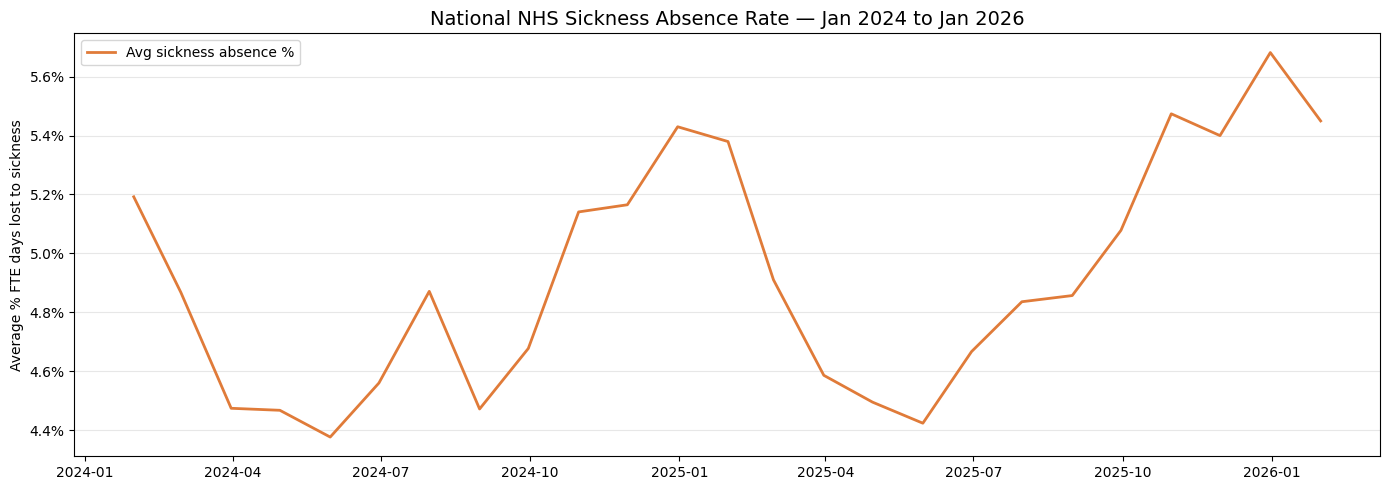

Chart saved.


In [13]:
# Chart 2: National sickness absence trend (corrected)
national_sick = sickness.groupby('date')['sickness_rate'].mean().reset_index()

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(national_sick['date'], national_sick['sickness_rate'], 
        color='#e07b39', linewidth=2, label='Avg sickness absence %')
ax.set_title('National NHS Sickness Absence Rate — Jan 2024 to Jan 2026', fontsize=14)
ax.set_ylabel('Average % FTE days lost to sickness')
ax.set_xlabel('')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.1f}%'))
ax.legend()
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('../static/chart_national_sickness_trend.png', dpi=150)
plt.show()
print("Chart saved.")

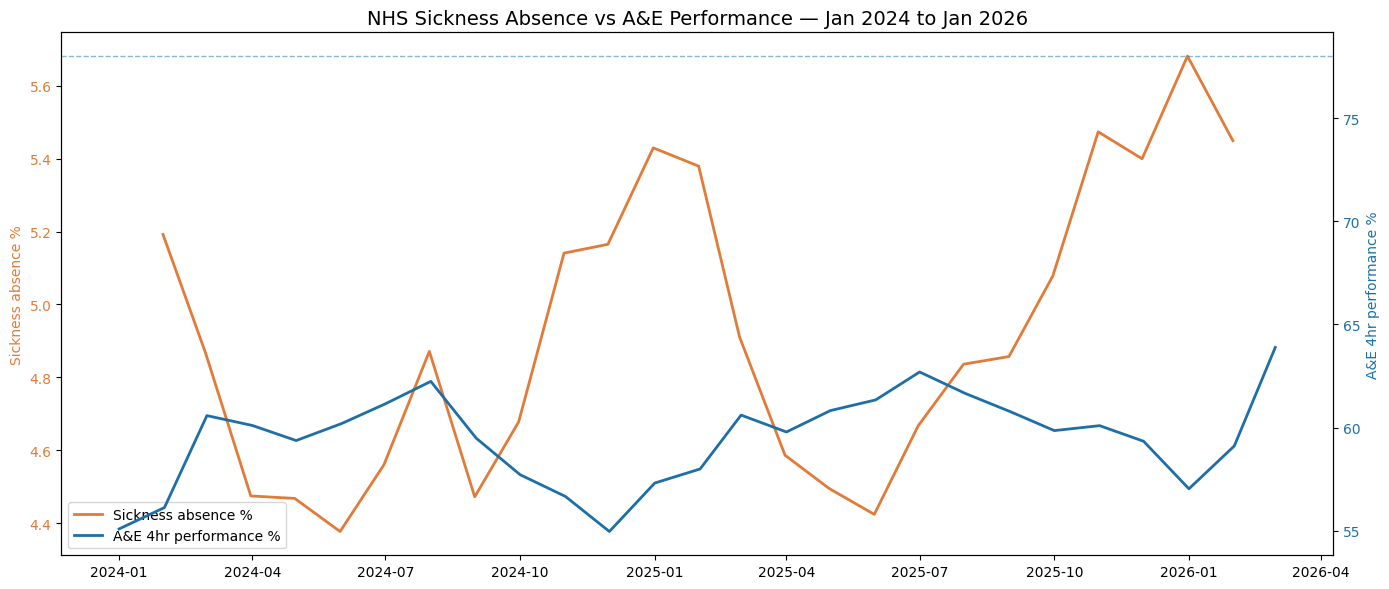

Chart saved.


In [14]:
# Chart 3: Overlay both trends to show the relationship visually
fig, ax1 = plt.subplots(figsize=(14, 6))

ax1.plot(national_sick['date'], national_sick['sickness_rate'],
         color='#e07b39', linewidth=2, label='Sickness absence %')
ax1.set_ylabel('Sickness absence %', color='#e07b39')
ax1.tick_params(axis='y', labelcolor='#e07b39')

ax2 = ax1.twinx()
ae_trimmed = national_ae[national_ae['date'] >= '2024-01-01']
ax2.plot(ae_trimmed['date'], ae_trimmed['perf_pct'],
         color='#1d6fa5', linewidth=2, label='A&E 4hr performance %')
ax2.axhline(y=78, color='#1d6fa5', linestyle='--', linewidth=1, alpha=0.5)
ax2.set_ylabel('A&E 4hr performance %', color='#1d6fa5')
ax2.tick_params(axis='y', labelcolor='#1d6fa5')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower left')

plt.title('NHS Sickness Absence vs A&E Performance — Jan 2024 to Jan 2026', fontsize=14)
plt.tight_layout()
plt.savefig('../static/chart_overlay.png', dpi=150)
plt.show()
print("Chart saved.")

C:\Users\plars\AppData\Local\Temp\ipykernel_24644\2050005487.py:3: RuntimeWarning: invalid value encountered in scalar divide
  lambda x: (x['A&E attendances Type 1'].sum() - x['Attendances over 4hrs Type 1'].sum()) /


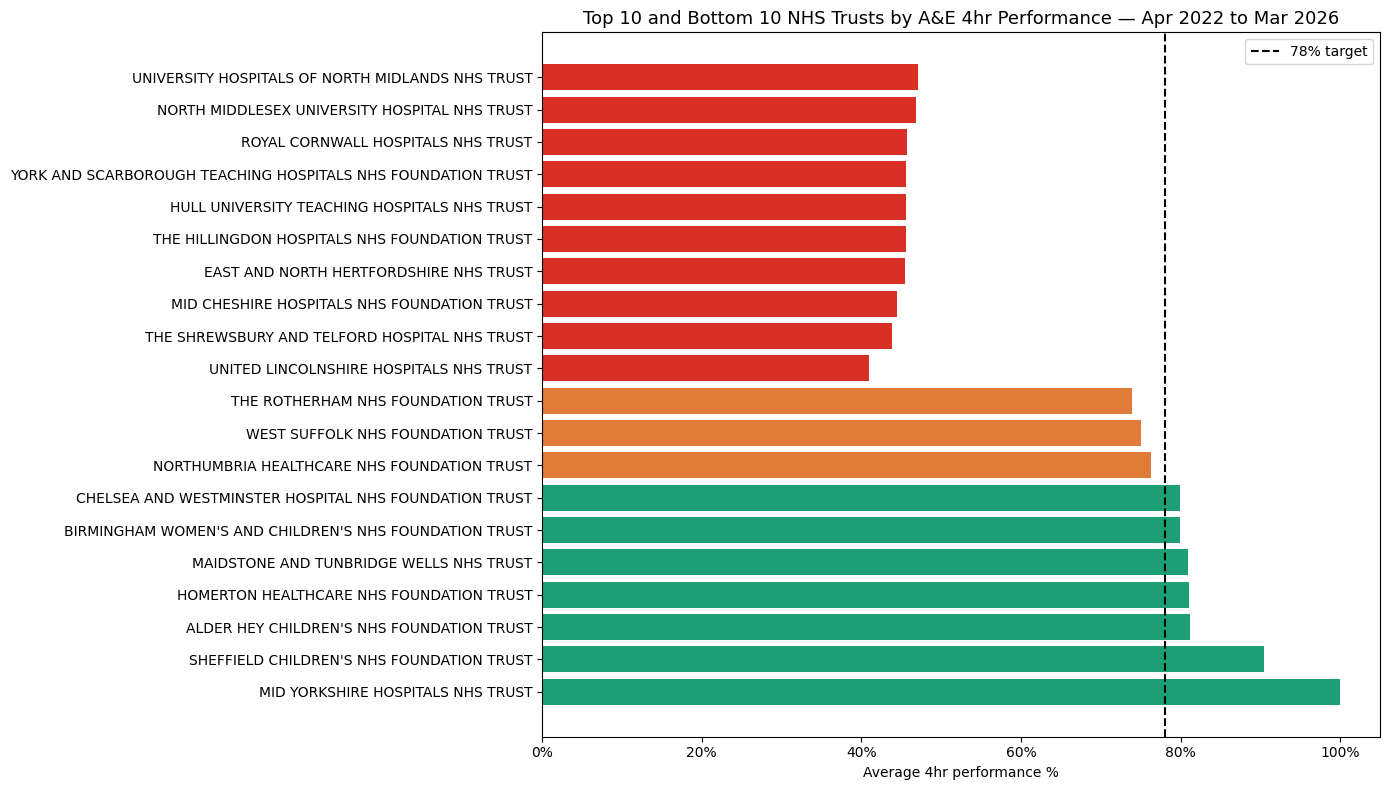

Chart saved.


In [15]:
# Chart 4: Top 10 and Bottom 10 trusts by average A&E performance
trust_avg = ae.groupby(['Org Code', 'Org name']).apply(
    lambda x: (x['A&E attendances Type 1'].sum() - x['Attendances over 4hrs Type 1'].sum()) /
    x['A&E attendances Type 1'].sum() * 100
).reset_index()
trust_avg.columns = ['org_code', 'org_name', 'avg_perf']

# Remove rows with zero attendances
trust_avg = trust_avg[trust_avg['avg_perf'] > 0].dropna()

top10 = trust_avg.nlargest(10, 'avg_perf')
bottom10 = trust_avg.nsmallest(10, 'avg_perf')
combined = pd.concat([top10, bottom10])

colors = ['#1d9e75' if x >= 78 else '#e07b39' if x >= 60 else '#d93025' 
          for x in combined['avg_perf']]

fig, ax = plt.subplots(figsize=(14, 8))
bars = ax.barh(combined['org_name'], combined['avg_perf'], color=colors)
ax.axvline(x=78, color='black', linestyle='--', linewidth=1.5, label='78% target')
ax.set_title('Top 10 and Bottom 10 NHS Trusts by A&E 4hr Performance — Apr 2022 to Mar 2026', fontsize=13)
ax.set_xlabel('Average 4hr performance %')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.legend()
plt.tight_layout()
plt.savefig('../static/chart_trust_league.png', dpi=150)
plt.show()
print("Chart saved.")

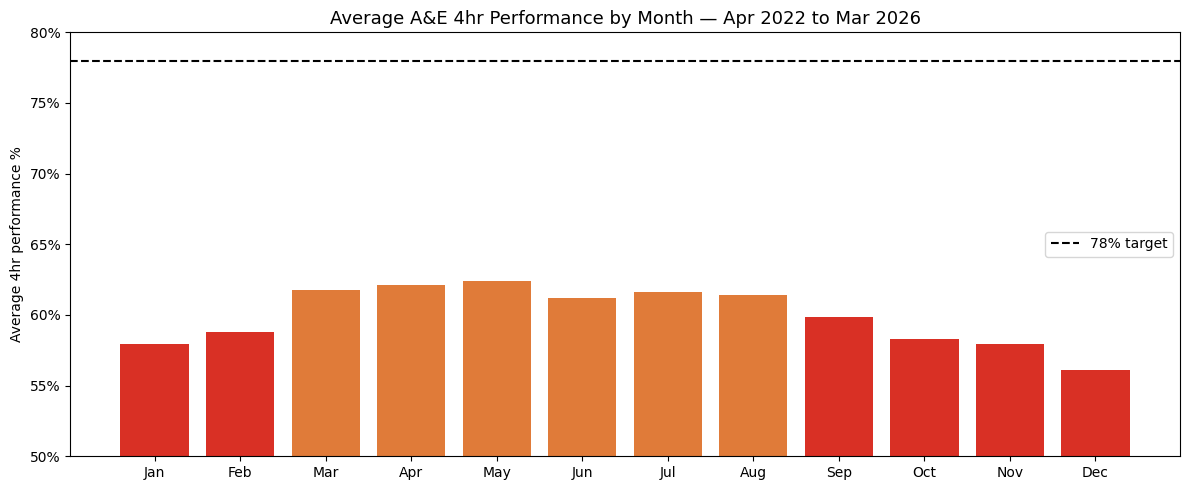

Chart saved.


In [16]:
# Chart 5: Seasonal patterns - average performance by month
ae['month'] = ae['date'].dt.month
ae['month_name'] = ae['date'].dt.strftime('%b')

seasonal = ae.groupby(['month', 'month_name']).apply(
    lambda x: (x['A&E attendances Type 1'].sum() - x['Attendances over 4hrs Type 1'].sum()) /
    x['A&E attendances Type 1'].sum() * 100
).reset_index()
seasonal.columns = ['month', 'month_name', 'avg_perf']
seasonal = seasonal.sort_values('month')

colors = ['#d93025' if x < 60 else '#e07b39' if x < 65 else '#1d6fa5' 
          for x in seasonal['avg_perf']]

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(seasonal['month_name'], seasonal['avg_perf'], color=colors)
ax.axhline(y=78, color='black', linestyle='--', linewidth=1.5, label='78% target')
ax.set_title('Average A&E 4hr Performance by Month — Apr 2022 to Mar 2026', fontsize=13)
ax.set_ylabel('Average 4hr performance %')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0f}%'))
ax.set_ylim(50, 80)
ax.legend()
plt.tight_layout()
plt.savefig('../static/chart_seasonal.png', dpi=150)
plt.show()
print("Chart saved.")